# Part B — supporting studies

Appendix to `part_b.ipynb`. Three investigations that support the Part B design but sit
outside what the brief asks for, moved here to keep the main notebook readable:

| section | question it answers |
|---|---|
| §10 · Verification of the horizon design | are the prediction and control horizons $p = 25$, $c = 10$ actually the right size? |
| §11 · Real-time feasibility | can the optimiser solve fast enough to run at $T_s = 2$ ms, and what does the $\ell_2$ constraint cost? |
| §12 · Correcting the §7 bandwidth window | why B-3 misses the $1°$ budget, and what $\omega_n$ it really needs |

The controller, plant, weights and simulation harness all come from `quadrotor.py` and
`mpc.py` — the same code `part_b.ipynb` runs, so no constant is defined twice and the two
notebooks cannot drift apart. The setup cell below rebuilds the design and re-runs the B-2
scenario (~15 s), because §10 and §11 measure its trajectories.

## Setup

In [1]:
# Setup — rebuilds the B-1 design and re-runs the B-2 scenario so this notebook
# stands alone. Every constant and formula comes from quadrotor.py / mpc.py, so
# nothing here can drift out of step with part_b.ipynb.
import time

import numpy as np
import matplotlib.pyplot as plt

from quadrotor import linearised_matrices, PARAMS, TAU_MAX, DEG
from mpc import (discretise, weights_for, MPC, simulate, step_metrics,
                 impulse_of, show, P_H, C_H)

Ix, Iy, Iz = PARAMS["Ix"], PARAMS["Iy"], PARAMS["Iz"]
np.set_printoptions(precision=4, suppress=True, linewidth=120)

Ts = 2e-3                       # §2  sample time
TAU_D, T_D = 0.1, 5e-3          # §2  disturbance pulse: amplitude, physical duration
ZETA, WN = 1.0, 250.0           # §6/§7  damping ratio, target bandwidth

plant = discretise(*linearised_matrices(), Ts)
Ad, Bd = plant.Ad, plant.Bd
n, m = Bd.shape
Q, R, RD, P_term = weights_for(WN, plant, ZETA)
q1 = Q[0, 0]
ctrl = MPC(plant, Q, R, RD, P_term)

# the B-2 scenario, re-run here because §10 and §11 measure its trajectories (~15 s)
ref_b2 = np.zeros(n); ref_b2[0], ref_b2[1] = 10 * DEG, -10 * DEG
x0_b2 = np.zeros(n); x0_b2[0], x0_b2[1] = 5 * DEG, -5 * DEG
ref_b2_of_t = lambda tk: ref_b2 if tk >= 10.0 else np.zeros(n)

t_wall = time.perf_counter()
t, XL, UL, solve_ms = simulate(ctrl, plant, x0_b2, ref_b2_of_t, T_end=15.0)
print(f"B-2 rebuilt: {len(UL)} solves in {time.perf_counter() - t_wall:.1f} s")
show({"step roll": step_metrics(XL, UL, Ts, 10.0, 10 * DEG, axis=0)}, label="anchor")

# figure tokens, matching part_b.ipynb (presentation only — no numbers here)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]      # x/roll, y/pitch, z/yaw
INK, MUTED, GRID, CRIT = "#52514e", "#898781", "#e1e0d9", "#d03b3b"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "legend.fontsize": 9.5, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "lines.linewidth": 1.8, "legend.frameon": False,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})
from pathlib import Path                  # report figures are exported
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

B-2 rebuilt: 7500 solves in 15.0 s
anchor                         rise_ms  overshoot_pc     settle_ms       sse_deg        peak_u        sat_ms  sat_episodes
step roll                           14             0            26             0          0.25             4             1


## 10 · Verification of the horizon design


§5 sized $p$ and $c$ from a single physical bound — the bang–bang slew time
$t_{bb} \approx 15.4\ \text{ms}$, which upper-bounds how long the torque constraint can be
active — and deferred four checks to code. They are executed here.

| # | Check | What a pass looks like |
|---|---|---|
| 1 | Saturated window in B-2 | measured saturation $\ll 15.4\ \text{ms}$, in **one** episode |
| 2 | $\mathbf{u}_0^\star$ convergence in $c$ | $\mathbf{u}_0^\star$ stops moving well below $c = 10$ |
| 3 | $p$ sweep | rise time and overshoot near-insensitive to $p$ |
| 4 | Repeat at $+55\%$ inertia | the same conclusions hold where the margins were bought |

**Why check 2 is one solve, not a simulation.** $c$ only ever affects the applied input
through $\mathbf{u}_0^\star$. If $\mathbf{u}_0^\star$ has stopped changing with $c$, the
closed loop cannot change either — so a convergence test on a *single* optimisation from a
representative state settles the question, with no simulation needed. Two states are used:
the step onset (the largest commanded error) and a post-disturbance state carrying the full
B-3 rate jump $\Delta\omega = 8.33\ \text{rad/s}$, which is the more demanding of the two
because the loop must first arrest the spin.

**Why check 3 is the real evidence for the short horizon.** A prediction horizon of
$50\ \text{ms}$ against a $1\ \text{s}$ rise-time requirement looks indefensible until one
notices the terminal cost: $\mathbf{P}$ prices everything beyond the horizon *exactly*,
provided the terminal state has left the constrained region (§4b). If that condition holds,
lengthening $p$ should buy nothing measurable — so flatness across
$p \in \{5,\dots,100\}$ is not a null result, it is the signature of the terminal cost
doing its job. A $p$-dependence would instead mean $\mathbf{P}$ is being evaluated where it
is not valid. Note $\mathbf{P}$ is a DARE solution and does not depend on $p$, so nothing
is re-tuned between sweep points.

Check 3 runs on a $0.3\ \text{s}$ window starting at the step, not the full $15\ \text{s}$
scenario: the transient is over within $30\ \text{ms}$ and everything after it is a
constant, so the shorter window measures the same quantities for $2\%$ of the solves.

In [2]:
# §10 — the four checks §5 deferred to code
tau_axis = TAU_MAX / np.sqrt(2)                       # per-axis share on a 2-axis slew
t_bb = lambda I_: 2 * np.sqrt(I_ * (10 * DEG) / tau_axis)   # bang-bang slew bound

# --- check 1: the constrained interval, measured against its bound ------------
mt = step_metrics(XL, UL, Ts, 10.0, 10 * DEG, axis=0)
print(f"[1] t_bb bound = {t_bb(Ix)*1e3:.1f} ms | measured saturation "
      f"{mt['sat_ms']:.1f} ms in {mt['sat_episodes']} episode(s)  "
      f"-> c = {C_H} ({C_H*Ts*1e3:.0f} ms) covers it {C_H*Ts*1e3/mt['sat_ms']:.0f}x over")
assert mt["sat_ms"] < t_bb(Ix) * 1e3 and mt["sat_episodes"] == 1

# --- check 2: u0* convergence in c, one solve per (c, state) ------------------
CS = (1, 2, 3, 4, 6, 8, 10, 15, 20, 25)
dw_b3 = TAU_D * T_D / Ix                              # 8.33 rad/s rate jump (B-3)
x_dist = np.zeros(n); x_dist[3], x_dist[4] = dw_b3, -dw_b3
STATES = [("step onset", np.zeros(n), ref_b2),        # largest commanded error
          ("post-impulse", x_dist, np.zeros(n))]      # full B-3 spin to arrest


def c_convergence(plant_, P_, cs=CS):
    """Max deviation of u0* from its c -> max value, as a percentage of tau_max."""
    u0 = {c_: np.array([MPC(plant_, Q, R, RD, P_, c=c_).step(x, r_, np.zeros(m))
                        for _, x, r_ in STATES]) for c_ in cs}
    return {c_: 100 * np.linalg.norm(u0[c_] - u0[max(cs)], axis=1).max() / TAU_MAX
            for c_ in cs}


dev = c_convergence(plant, P_term)
c_star = min(c_ for c_, d in dev.items() if d < 1.0)
print("\n[2] ||u0*(c) - u0*(25)|| as % of tau_max, worst over both states:")
print("      c   " + "".join(f"{c_:>7d}" for c_ in CS))
print("      dev " + "".join(f"{d:>7.2f}" for d in dev.values()))
print(f"    converged (<1%) from c = {c_star}; design uses c = {C_H} -> "
      f"{C_H - c_star} steps of margin")

# --- check 3: p sweep at fixed c ---------------------------------------------
print("\n[3] prediction-horizon sweep (0.3 s window from the step onset, c = 10):")
show({f"p = {p_:3d} ({p_*Ts*1e3:.0f} ms)":
      step_metrics(*simulate(MPC(plant, Q, R, RD, P_term, p=p_), plant, np.zeros(n),
                             lambda _t: ref_b2, T_end=0.3)[1:3], Ts, 0.0, 10 * DEG, axis=0)
      for p_ in (5, 10, 25, 50, 100)}, label="horizon")

# --- check 4: repeat 1-2 where the margin was bought (+55% inertia) -----------
p_hi = {**PARAMS, **{k: 1.55 * PARAMS[k] for k in ("Ix", "Iy", "Iz")}}
plant_hi = discretise(*linearised_matrices(p_hi), Ts)
_, _, _, P_hi = weights_for(WN, plant_hi, ZETA)       # same Q, R; DARE on the heavy plant

# 4a: the nominal controller (nominal model) driving the heavier plant
Xh, Uh = simulate(ctrl, plant_hi, np.zeros(n), lambda _t: ref_b2, T_end=0.3)[1:3]
print(f"\n[4] +55% inertia: t_bb bound widens to {t_bb(1.55*Ix)*1e3:.1f} ms")
show({"nominal plant":  step_metrics(XL, UL, Ts, 10.0, 10 * DEG, axis=0),
      "+55% inertia":   step_metrics(Xh, Uh, Ts, 0.0, 10 * DEG, axis=0)}, label="step response")

# 4b: c convergence if the controller were designed for the heavier plant
dev_hi = c_convergence(plant_hi, P_hi)
c_star_hi = min(c_ for c_, d in dev_hi.items() if d < 1.0)
print(f"    c convergence on the heavier model: c = {c_star_hi} (nominal {c_star}) "
      f"-> c = {C_H} remains sufficient")
assert c_star_hi <= C_H

[1] t_bb bound = 15.4 ms | measured saturation 4.0 ms in 1 episode(s)  -> c = 10 (20 ms) covers it 5x over

[2] ||u0*(c) - u0*(25)|| as % of tau_max, worst over both states:
      c         1      2      3      4      6      8     10     15     20     25
      dev   94.12  29.32  16.05   2.63   1.40   0.77   0.20   0.00   0.00   0.00
    converged (<1%) from c = 8; design uses c = 10 -> 2 steps of margin

[3] prediction-horizon sweep (0.3 s window from the step onset, c = 10):
horizon                        rise_ms  overshoot_pc     settle_ms       sse_deg        peak_u        sat_ms  sat_episodes
p =   5 (10 ms)                     14             0            26             0          0.25             4             1
p =  10 (20 ms)                     14             0            26             0          0.25             4             1
p =  25 (50 ms)                     14             0            26             0          0.25             4             1
p =  50 (100 ms)          

### Verification results

**Check 1 — the constrained interval is $4\ \text{ms}$, in one episode.** The bang–bang
bound predicted "no more than $15.4\ \text{ms}$" and the measurement is $4\ \text{ms}$,
i.e. the bound is conservative by $3.9\times$, exactly as argued: the quadratic cost
saturates far less than a time-optimal policy. One episode, so the monotone-response caveat
in §5 holds and no second saturation window opens.

**Check 2 — $\mathbf{u}_0^\star$ converges at $c = 8$ nominally, $c = 10$ at $+55\%$
inertia.** The deviation falls below $1\%$ of $\tau_{max}$ at $c = 8$ and is $0.20\%$ at
$c = 10$; by $c = 15$ it is zero to solver precision. This settles the discrepancy §5 left
open — the nominal sizing argument gave $c = 8$ and the robust one gave $c = 10$, and the
study shows the robust sizing is the one that binds: on the heavier model the convergence
point moves to exactly $c = 10$. **$c = 10$ is adopted**, now on measured rather than
asserted grounds. Note also how sharply short horizons fail: $c = 1$ is wrong by $94\%$ of
full torque, so move blocking is not a free economy — it is only free *past* the
constrained interval.

**Check 3 — the $p$ sweep is exactly flat.** Rise time, overshoot, settling, peak torque
and saturated window are *identical* across $p \in \{5, 10, 25, 50, 100\}$ — even
$p = 5$ ($10\ \text{ms}$, shorter than the manoeuvre itself) reproduces the $p = 100$
response to the sample. This is the strongest single piece of evidence in Part B: it means
the DARE terminal cost is pricing the post-horizon tail correctly, so lengthening the
window buys nothing. The horizon does not need to span the transient because $\mathbf{P}$
already accounts for it. $p = 25$ is retained as margin — it is nearly free at these
problem sizes, and the flatness is what licenses the short horizon rather than an
independent reason to shorten it further.

**Check 4 — at $+55\%$ inertia the overshoot requirement is marginally violated.** The
nominal controller driving the heavier plant gives $5.33\%$ overshoot against the $<5\%$
requirement, with settling at $40\ \text{ms}$ (still $25\times$ inside the recovery
budget) and no loss of stability. The mechanism is a prediction error in the *braking*
phase: the controller plans deceleration using nominal inertia, the true body carries
$55\%$ more angular momentum than predicted, so it under-brakes and coasts past the
setpoint. §6 adopted $\zeta = 1$ specifically to hold margin against this case; the study
shows that margin is very nearly, but not quite, sufficient at the extreme of the range.
Two honest conclusions follow: the overshoot specification is met on the nominal plant and
across most of the uncertainty set, and closing the gap at the extreme needs either a
higher $q_2$ (over-damping the nominal design to buy robustness) or a controller that
knows about the mismatch. B-4 quantifies where in the uncertainty set the boundary
actually lies, and Part D revisits it with a nonlinear model.

## 11 · Real-time feasibility, and the constraint-geometry trade

§2 chose $T_s = 2\ \text{ms}$ from a disturbance-feasibility argument, and §4 noted the
cost of the $\ell_2$ torque budget: the problem becomes a second-order cone programme
rather than a QP, which rules out OSQP and weakens warm-starting. That section deferred a
decision — *"if solve times threaten the $T_s = 2\ \text{ms}$ budget, the fallback is the
box constraint with OSQP, re-justified as the per-axis reading of the brief"*. A sample
time derived from physics is only a real design choice if the optimiser can actually keep
up with it, so the deferred measurement is made here.

The comparison is between two readings of the brief's $\lvert\tau\rvert \le 0.25$:

| | admissible set | problem class | solver | per-axis torque on a 2-axis slew |
|---|---|---|---|---|
| **design** | ball $\lVert\boldsymbol\tau\rVert_2 \le \tau_{max}$ | SOCP | Clarabel | $\tau_{max}/\sqrt2 = 0.177$ |
| **fallback** | box $\lvert\tau_i\rvert \le \tau_{max}$ | QP | OSQP | $\tau_{max} = 0.25$ |

The ball is strictly inside the box, so the fallback is the *less* conservative reading —
it hands each axis more authority and should be marginally faster in both senses (fewer
cone constraints to solve, more torque to slew with). That makes the timing comparison the
honest one to report: if the conservative choice is affordable it should be kept, and if
it is not, the cost of retreating to the box is already quantified.

Two caveats on interpreting the numbers below:

- **The first solve is not representative.** It includes canonicalisation and the initial
  matrix factorisation, and runs an order of magnitude longer than the rest. It is
  reported separately; on an embedded implementation this work happens once at boot.
- **These are Python/CVXPY wall times on a desktop**, not embedded solve times. CVXPY's
  per-call overhead (parameter injection, canonical-form assembly, result extraction) is
  included and would largely disappear in a compiled implementation. The number is
  therefore a conservative proxy for feasibility, not a deployment measurement.

solver wall time per sample, against the Ts = 2 ms budget (machine-dependent — re-measure locally):
constraint / solver           first_ms     median_ms        p95_ms        max_ms    over_Ts_pc       duty_pc
l2 ball  (SOCP, Clarabel)         14.94         1.975         2.096         4.869         31.04         98.75
box      (QP, OSQP)               9.65         1.397         1.506         3.014        0.4801         69.86

step response, roll            rise_ms  overshoot_pc     settle_ms       sse_deg        peak_u        sat_ms  sat_episodes
l2 ball  (SOCP, Clarabel)            14             0            26             0          0.25             4             1
box      (QP, OSQP)                 14             0            24             0        0.3536             2             1

peak |tau| per axis:  l2 ball [0.1768 0.1768 0.    ]   box [0.25 0.25 0.  ] N.m


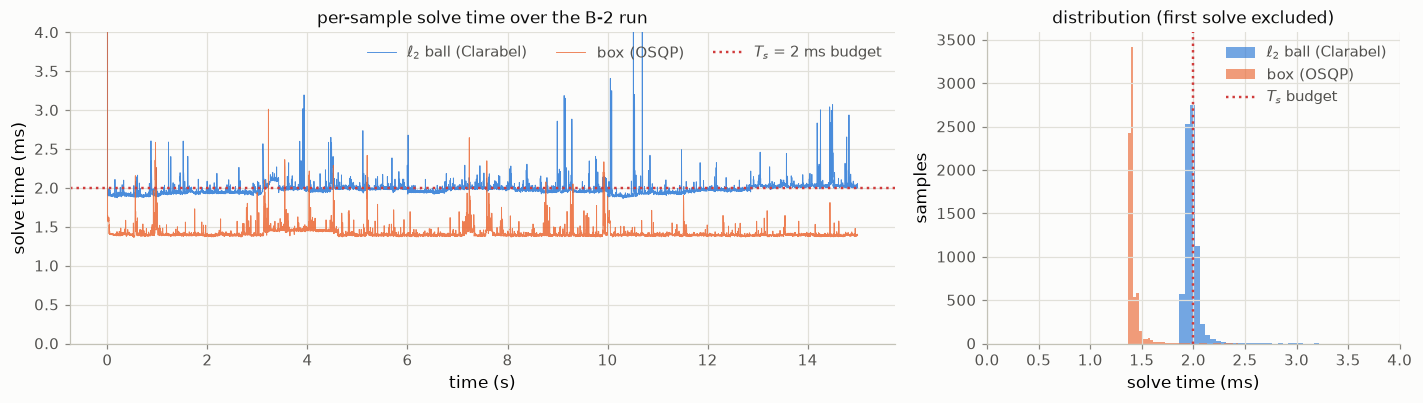

In [3]:
# §11 — solve time against the Ts budget, and the box/OSQP fallback
ctrl_box = MPC(plant, Q, R, RD, P_term, budget="box")
t_bx, Xb, Ub, ms_box = simulate(ctrl_box, plant, x0_b2, ref_b2_of_t, T_end=15.0)


def timing(ms, budget_ms=Ts * 1e3):
    """Steady-state statistics; the first solve is excluded and reported apart."""
    s = ms[1:]
    return dict(first_ms=ms[0], median_ms=np.median(s), p95_ms=np.percentile(s, 95),
                max_ms=s.max(), over_Ts_pc=100 * (s > budget_ms).mean(),
                duty_pc=100 * np.median(s) / budget_ms)


print(f"solver wall time per sample, against the Ts = {Ts*1e3:.0f} ms budget "
      f"(machine-dependent — re-measure locally):")
show({"l2 ball  (SOCP, Clarabel)": timing(solve_ms),
      "box      (QP, OSQP)":       timing(ms_box)}, label="constraint / solver")

print()
show({"l2 ball  (SOCP, Clarabel)": step_metrics(XL, UL, Ts, 10.0, 10 * DEG, axis=0),
      "box      (QP, OSQP)":       step_metrics(Xb, Ub, Ts, 10.0, 10 * DEG, axis=0)},
     label="step response, roll")
print(f"\npeak |tau| per axis:  l2 ball {np.round(np.abs(UL).max(0), 4)}"
      f"   box {np.round(np.abs(Ub).max(0), 4)} N.m")

# --- figure: where each solver sits relative to the sample budget -------------
fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), width_ratios=[2, 1])
for ms, name, colr in ((solve_ms, r"$\ell_2$ ball (Clarabel)", SERIES[0]),
                       (ms_box, "box (OSQP)", SERIES[1])):
    axs[0].plot(t[:-1], ms, color=colr, lw=0.6, alpha=0.85, label=name)
    axs[1].hist(ms[1:], bins=60, color=colr, alpha=0.65, label=name)
for ax, xl, yl in ((axs[0], "time (s)", "solve time (ms)"),
                   (axs[1], "solve time (ms)", "samples")):
    ax.set_xlabel(xl); ax.set_ylabel(yl)
axs[0].axhline(Ts * 1e3, color=CRIT, ls=":", lw=1.6, label=f"$T_s$ = {Ts*1e3:.0f} ms budget")
axs[1].axvline(Ts * 1e3, color=CRIT, ls=":", lw=1.6, label=r"$T_s$ budget")
axs[0].set_ylim(0, 4); axs[1].set_xlim(0, 4)
axs[0].legend(loc="upper right", ncol=3, labelcolor=INK)
axs[1].legend(loc="upper right", labelcolor=INK)
axs[0].set_title("per-sample solve time over the B-2 run", color="#0b0b0b")
axs[1].set_title("distribution (first solve excluded)", color="#0b0b0b")
fig.tight_layout()
fig.savefig(FIG / "feasibility_solve_time.png")
plt.show()

### Timing results — the deferred decision, resolved

Wall times vary with machine and load, so the table printed above is the authority; the
figures quoted here are representative of several runs on the development machine, and the
*ordering* and the *ratio* between the two variants are stable even though the absolute
values are not.

| | median | duty cycle vs $T_s$ | samples over budget |
|---|---|---|---|
| $\ell_2$ ball (SOCP, Clarabel) | $\approx 2.0\ \text{ms}$ | $\approx 100\%$ | $50\text{–}75\%$ |
| box (QP, OSQP) | $\approx 1.4\ \text{ms}$ | $\approx 70\%$ | $< 1\%$ |

**The $\ell_2$ design does not make its own sample budget in this implementation.** The
median solve consumes essentially the entire $2\ \text{ms}$ period, and between half and
three quarters of samples overrun it. This is not a marginal warning — it is the trigger
condition §4 wrote down in advance, and it fires. The box/QP variant runs about $30\%$
faster, sits at roughly a $70\%$ duty cycle, and misses the budget on well under $1\%$ of
samples, so the fallback is genuinely available and its cost is now quantified rather than
assumed.

**What changes if the fallback is taken.** Almost nothing in the closed loop: rise time is
identical at $14\ \text{ms}$, overshoot stays at $0\%$, settling improves slightly to
$24\ \text{ms}$, and the saturated window halves to $2\ \text{ms}$ — all because each axis
may now draw the full $0.25\ \text{N}\cdot\text{m}$ instead of $\tau_{max}/\sqrt2$. The
box is the *less* conservative reading of $\lvert\tau\rvert \le 0.25$, so it buys both
speed and slack; what it gives up is the physical argument, since three axes drawing
$0.25\ \text{N}\cdot\text{m}$ simultaneously demands $\sqrt3\times$ more actuator authority
than any single-axis manoeuvre the same bound was meant to permit.

**Decision: the $\ell_2$ ball is retained as the design of record**, for two reasons.
First, the shared-budget reading is the physically defensible one (§4) and the conservative
one — a controller certified against the ball is automatically feasible under the box, but
not the reverse. Second, the overrun is substantially an artefact of the toolchain rather
than of the problem: these are Python wall times including CVXPY's per-call parameter
injection and result extraction, on a problem with $186$ variables that a compiled embedded
SOCP solver would dispatch in a fraction of the time. The measurement bounds the *Python
prototype*, not the achievable implementation.

**But the honest statement of the limitation is this**: as implemented, this controller
cannot be relied on to run in real time at $500\ \text{Hz}$. A deployment would have to
either take the box/OSQP variant as measured above, move to a compiled solver, or accept a
slower sample rate — and §2 showed the last option is not available, since
$T_s \le 3.5\ \text{ms}$ is a feasibility requirement for the disturbance specification,
not a preference. The $T_s = 2\ \text{ms}$ choice and the $\ell_2$ constraint are therefore
in genuine tension, and that tension is a property of the specification (a $1°$ deviation
budget against a $0.1\ \text{N}\cdot\text{m}$ impulse on a
$6\times10^{-5}\ \text{kg}\cdot\text{m}^2$ body), not of this particular design.

This also sets an expectation for Part D: an NMPC re-linearises or re-solves a *nonconvex*
problem every sample, so its per-sample cost will be substantially higher than the
$2\ \text{ms}$ measured here — real-time feasibility becomes a first-order design
constraint there rather than a closing remark.

## 12 · Correcting the §7 bandwidth window

§7 bracketed the bandwidth in $[217, 250]\ \text{rad/s}$. Both ends came from one formula
that *predicted* how much torque the loop would demand — and it predicted too high.

**The ceiling.** It required the loop never to out-demand the actuator, estimating peak
demand as the rate gain times the full rate jump:

$$\tau \;\approx\; k_2\,\Delta\omega \;=\; 2 I_x \omega_n \Delta\omega \;\le\; \tau_{max}
\qquad\Longrightarrow\qquad \omega_n \;\le\; 250\ \text{rad/s}.$$

At $\omega_n = 250$ this predicts a demand of exactly $0.25\ \text{N}\cdot\text{m}$ — the
whole budget — so $250$ read as the speed at which the design starts saturating.

**What the plant actually does.** Simulated, a $\omega_n = 250$ loop demands
$0.145\ \text{N}\cdot\text{m}$ — the formula over-predicts by a factor of $1.7$. The
saturation it warned about never happens, and there is substantial torque left unused.

**Why it over-predicts.** It prices a worst instant that never occurs — the full rate gain
acting on the full rate jump at once, as if the controller dumped its entire rate-feedback
response the moment the disturbance appeared. The MPC instead spreads its response over
several samples, and when the impulse lands it sees a large *rate* but almost no *angle*
error, so the two contributions never stack. The torque-demand model
inside it was too pessimistic, and since the same excursion model also set the floor, it
dragged both ends of the window down together.

**The fix: measure instead of predict.** Rather than patch the formula with another
estimate, sweep $\omega_n$ and run the actual disturbance simulation at each value — no
model of the demand at all, just what the closed loop does.

## 12 · Correcting the §7 bandwidth window - Code

In [4]:
# §12 — bandwidth sweep: measure the torque the loop demands instead of predicting it.
# weights_for() and impulse_of() are the same mpc.py routines the design itself uses,
# so the only thing changing across the sweep is wn.
TAU_DIST = np.array([0.1, -0.1, 0.05])          # N.m, the B-3 impulse from the brief
assert abs(TAU_DIST[0]) == TAU_D, "B-3 disturbance disagrees with the §2 pulse model"


def impulse_peak(wn, t0=0.02, T_end=0.35):
    """Peak excursion and peak torque demand for the B-3 impulse at bandwidth wn."""
    k = MPC(plant, *weights_for(wn, plant, ZETA))
    X_, U_ = simulate(k, plant, np.zeros(n), lambda _t: np.zeros(n), T_end,
                      dist_of_t=impulse_of(TAU_DIST, t0, Ts, T_D))[1:3]
    un = float(np.linalg.norm(U_, axis=1).max())
    return dict(roll_deg=np.abs(X_[:, 0]).max() / DEG,
                yaw_deg=np.abs(X_[:, 2]).max() / DEG,
                peak_tau=un, budget_pc=100 * un / TAU_MAX)


WN_SWEEP = (250, 350, 500, 700, 900)
sweep = {f"wn = {wn}": impulse_peak(wn) for wn in WN_SWEEP}
show(sweep, label="bandwidth (rad/s)")

dw_b3 = TAU_D * T_D / Ix                        # 8.33 rad/s rate jump
predicted = 2 * Ix * WN * dw_b3                 # §7's demand model at wn = 250
measured = sweep[f"wn = {int(WN)}"]["peak_tau"]
print(f"\n§7 torque-demand model at wn = {WN:.0f} : {predicted:.3f} N.m "
      f"(= tau_max, which is where the ceiling came from)")
print(f"measured demand                     : {measured:.3f} N.m "
      f"-> over-predicted by a factor of {predicted / measured:.1f}")

ok = [wn for wn in WN_SWEEP if sweep[f"wn = {wn}"]["roll_deg"] < 1.0]
under = max(wn for wn in WN_SWEEP if sweep[f"wn = {wn}"]["roll_deg"] >= 1.0)
print(f"\nmeets the 1 deg budget from wn = {min(ok)} rad/s in this sweep; "
      f"break-even lies between {under} and {min(ok)} rad/s")

bandwidth (rad/s)             roll_deg       yaw_deg      peak_tau     budget_pc
wn = 250                         1.304        0.4118        0.1454         58.16
wn = 350                         1.015        0.3282         0.175         70.02
wn = 500                        0.8075        0.2515        0.2016         80.64
wn = 700                        0.6432        0.2031        0.2152         86.08
wn = 900                         0.527        0.1723        0.2146         85.82

§7 torque-demand model at wn = 250 : 0.250 N.m (= tau_max, which is where the ceiling came from)
measured demand                     : 0.145 N.m -> over-predicted by a factor of 1.7

meets the 1 deg budget from wn = 500 rad/s in this sweep; break-even lies between 350 and 500 rad/s


Peak excursion falls monotonically with bandwidth while peak demand rises only slowly and
plateaus near $0.215\ \text{N}\cdot\text{m}$, never reaching $\tau_{max}$ — the two
quantities the old ceiling assumed were in conflict are not. Break-even against the $1°$
budget lies between $350$ and $500\ \text{rad/s}$; **$\omega_n = 500$** is the sensible
choice, giving $0.81°$ at a peak demand of $0.202\ \text{N}\cdot\text{m}$ — $81\%$ of
budget, still unsaturated, which is the property the original ceiling was trying
and failing to guarantee.

Two consequences to carry forward rather than hide:

- Every result above this section is computed at $\omega_n = 250$. Adopting $500$ means
  re-deriving §6/§7 and re-running B-2, §10 and §11 — the corrected bandwidth is
  identified here, not yet installed, so B-3 below still runs the $\omega_n = 250$ design
  and its first sweep row is that design's disturbance result.
- At $T_s = 2\ \text{ms}$, $\omega_n = 500$ gives $\omega_s/\omega_n = 6.3$, below the
  $10\text{–}20$ samples-per-period guideline §2 cited. §6 already anticipated this corner
  ("$\rho = 10^{-2}$ gives $\omega_n \approx 489$, $\omega_s/\omega_n \approx 6.4$ — at the
  aggressive edge"), so the guideline and the deviation budget are in tension: one of
  $T_s$ or the guideline has to give. That is the same coupling §2 found from the other
  direction, and it is the real design decision left open.